# Praktikum Minggu 6 — Filter Spasial
Low Pass Filter, High Pass Filter, Point Detection, Line Detection, Edge Detection

Notebook ini berisi **D. Praktikum Filter** dan **Tugas Praktikum**.
Citra yang dipakai ada pada folder `data/` (`mandrill.tiff`, `lena.jpg`, `djawatan.jpg`).

In [1]:
# ===== Cell Identitas =====
NAMA = 'Radit Firansah'
NIM  = '244107020196'
print(NAMA, NIM)

Radit Firansah 244107020196


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from pathlib import Path

# ===== AKSES DATASET DARI GOOGLE DRIVE =====
# Colab : tambahkan folder Drive yang dibagikan ke "My Drive"
#         (klik kanan folder > Add shortcut to Drive), lalu jalankan sel ini.
# Lokal : taruh folder dataset di ./PCVK (opsional).
try:
    from google.colab import drive
    drive.mount('/content/drive')
    _MYDRIVE = Path('/content/drive/MyDrive')
except Exception:
    _MYDRIVE = Path('.')


def _cari_dataset():
    kandidat = [_MYDRIVE / 'PCVK' / 'Images', _MYDRIVE / 'PCVK']
    for p in kandidat:
        if (p / 'lena.jpg').exists():
            return p
    try:
        for p in _MYDRIVE.rglob('lena.jpg'):
            return p.parent
    except Exception:
        pass
    return kandidat[0]


CONTOH = _cari_dataset()   # citra contoh bersama (lena.jpg, djawatan.jpg, ...)
BASE = CONTOH / NIM        # citra pribadi (KTM1a-d.jpg, OBJ1.jpg, NIGHT1.jpg)
if not (BASE / 'KTM1a.jpg').exists():
    BASE = CONTOH          # fallback ke citra contoh bila folder NIM belum ada

print('CONTOH :', CONTOH)
print('BASE   :', BASE)

Bukan Google Colab, citra dibaca dari folder lokal "data".


## D. Praktikum Filter

### 1. Fungsi Konvolusi (tanpa library OpenCV)

Fungsi `convolution2d` mengikuti algoritma pada Bagian C: kernel digeser ke
seluruh piksel citra, lalu setiap piksel dihitung dari jumlah perkalian
kernel dengan piksel tetangganya. Parameter yang dipakai:
`image` (citra masukan), `kernel` (matriks filter), `stride` (besar pergeseran),
dan `padding` (border nol di sekeliling citra).

In [3]:
def convolution2d(image, kernel, stride=1, padding=0):
    # Citra diubah ke float agar hasil perkalian tidak terpotong
    image = image.astype(np.float32)
    kernel = np.array(kernel, dtype=np.float32)

    # Tambahkan border nol (padding) di sekeliling citra
    padded = np.pad(image, padding, mode='constant', constant_values=0)

    kernel_height, kernel_width = kernel.shape
    out_height = (padded.shape[0] - kernel_height) // stride + 1
    out_width = (padded.shape[1] - kernel_width) // stride + 1

    output = np.zeros((out_height, out_width), dtype=np.float32)

    # Geser kernel ke seluruh piksel citra
    for i in range(out_height):
        for j in range(out_width):
            row = i * stride
            col = j * stride
            area = padded[row:row + kernel_height, col:col + kernel_width]
            output[i, j] = np.sum(area * kernel)

    # Nilai dibatasi ke rentang 0-255 lalu diubah kembali ke uint8
    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

### 2. Load citra dan ubah menjadi citra keabuan

In [ ]:
DATA = CONTOH
print('Isi folder contoh:', sorted(p.name for p in DATA.iterdir()))

img = cv.imread(str(DATA / 'mandrill.tiff'))
if img is None:  # mandrill.tiff tidak ada di dataset Drive -> pakai lena.jpg
    img = cv.imread(str(DATA / 'lena.jpg'))
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Citra asli')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title(NIM + ' - Grayscale')
plt.axis('off')
plt.tight_layout()
plt.show()
print('Ukuran citra:', img_gray.shape)

### 3. Tentukan kernel dan panggil fungsi konvolusi

Contoh kernel **sharpen** seperti pada modul.

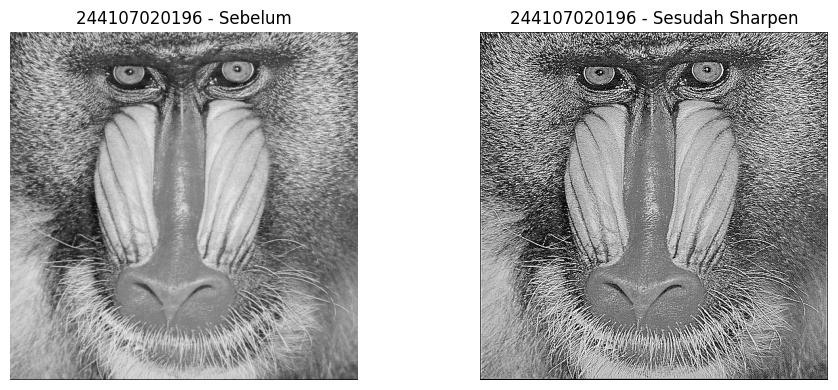

In [5]:
# Image sharpen
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title(NIM + ' - Sebelum')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(hasil_sharpen, cmap='gray')
plt.title(NIM + ' - Sesudah Sharpen')
plt.axis('off')
plt.tight_layout()
plt.show()

### 4. Image Filter: Average, Low Pass, dan High Pass

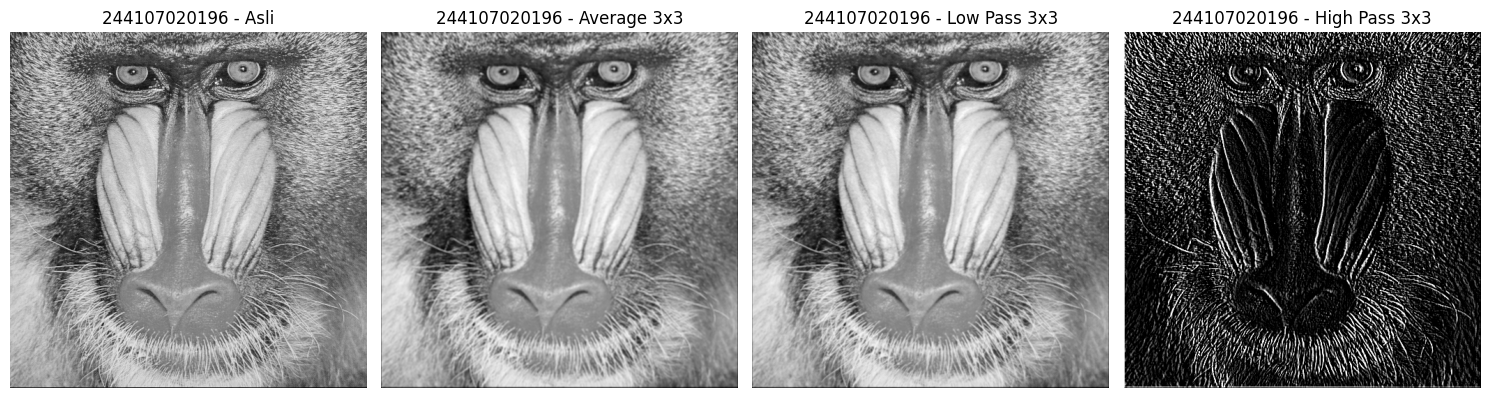

In [6]:
average_filter = np.ones((3, 3), dtype=np.float32) / 9
low_pass_filter = np.array([[1, 1, 1],
                            [1, 4, 1],
                            [1, 1, 1]], dtype=np.float32) / 16
high_pass_filter = np.array([[-1, 0, 1],
                             [-1, 0, 3],
                             [-3, 0, 1]], dtype=np.float32)

daftar_filter = [
    ('Average 3x3', average_filter),
    ('Low Pass 3x3', low_pass_filter),
    ('High Pass 3x3', high_pass_filter),
]

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(img_gray, cmap='gray')
plt.title(NIM + ' - Asli')
plt.axis('off')
for nomor, (nama, kernel) in enumerate(daftar_filter, 2):
    hasil = convolution2d(img_gray, kernel, 1, kernel.shape[0] // 2)
    plt.subplot(1, 4, nomor)
    plt.imshow(hasil, cmap='gray')
    plt.title(NIM + ' - ' + nama)
    plt.axis('off')
plt.tight_layout()
plt.show()

### 5. Filter lainnya

Sharpen, Emboss, Left Sobel Edge Detection, Canny Edge Detection (kernel
Laplacian), dan 21x21 Gaussian Blur. Kernel Gaussian dibuat dengan
`cv.getGaussianKernel` seperti pada modul.

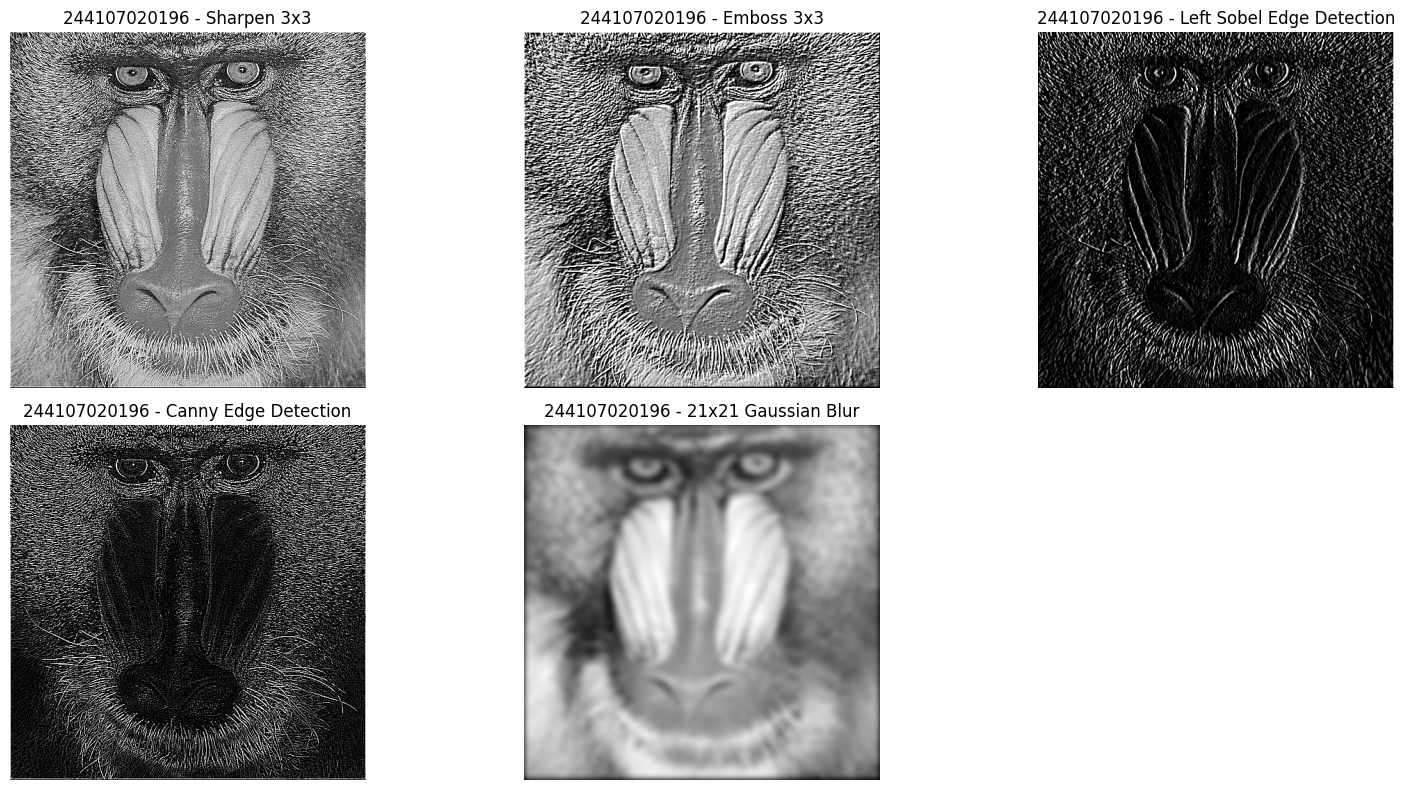

In [7]:
emboss = np.array([[-2, -1, 0],
                   [-1, 1, 1],
                   [0, 1, 2]], dtype=np.float32)
sobel_left = np.array([[1, 0, -1],
                       [2, 0, -2],
                       [1, 0, -1]], dtype=np.float32)
canny_edge = np.array([[-1, -1, -1],
                       [-1, 8, -1],
                       [-1, -1, -1]], dtype=np.float32)

# Generate kernel gaussian 21x21
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

daftar_filter = [
    ('Sharpen 3x3', kernel_sharpen),
    ('Emboss 3x3', emboss),
    ('Left Sobel Edge Detection', sobel_left),
    ('Canny Edge Detection', canny_edge),
    ('21x21 Gaussian Blur', gauss_kernel),
]

plt.figure(figsize=(16, 8))
for nomor, (nama, kernel) in enumerate(daftar_filter, 1):
    hasil = convolution2d(img_gray, kernel, 1, kernel.shape[0] // 2)
    plt.subplot(2, 3, nomor)
    plt.imshow(hasil, cmap='gray')
    plt.title(NIM + ' - ' + nama)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Tugas Praktikum

### Tugas 1 — Analisis: Mean Filter vs Median Filter pada Noise Salt and Pepper

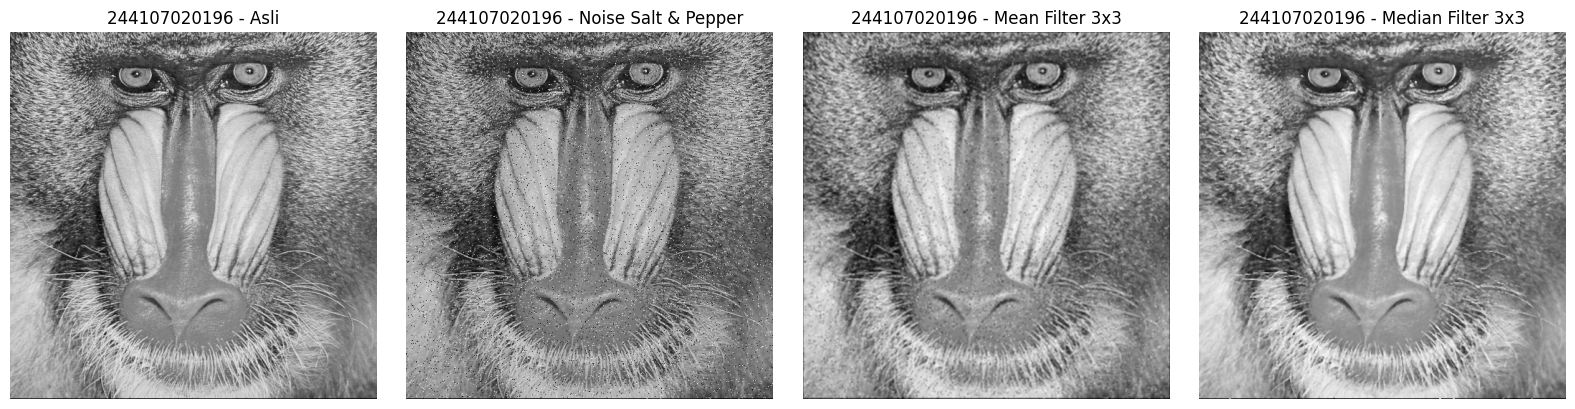

MSE citra noise  : 678.33
MSE mean filter  : 390.35
MSE median filter: 285.2


In [8]:
# 1a. Menambahkan noise salt and pepper ke citra grayscale
def tambah_salt_pepper(image, jumlah):
    hasil = image.copy()
    tinggi, lebar = image.shape
    for _ in range(jumlah):
        y = np.random.randint(0, tinggi)
        x = np.random.randint(0, lebar)
        hasil[y, x] = 0 if np.random.rand() < 0.5 else 255
    return hasil

np.random.seed(0)
img_noise = tambah_salt_pepper(img_gray, jumlah=10000)

# 1b. Mean filter 3x3 dan median filter 3x3
mean_kernel = np.ones((3, 3), dtype=np.float32) / 9
img_mean = convolution2d(img_noise, mean_kernel, 1, 1)
img_median = cv.medianBlur(img_noise, 3)

plt.figure(figsize=(16, 4))
for nomor, (gambar, judul) in enumerate([
    (img_gray, 'Asli'),
    (img_noise, 'Noise Salt & Pepper'),
    (img_mean, 'Mean Filter 3x3'),
    (img_median, 'Median Filter 3x3'),
], 1):
    plt.subplot(1, 4, nomor)
    plt.imshow(gambar, cmap='gray')
    plt.title(NIM + ' - ' + judul)
    plt.axis('off')
plt.tight_layout()
plt.show()

# 1c. Perbandingan kuantitatif terhadap citra asli
def mse(asli, hasil):
    return np.mean((asli.astype(np.float32) - hasil.astype(np.float32)) ** 2)

print('MSE citra noise  :', round(mse(img_gray, img_noise), 2))
print('MSE mean filter  :', round(mse(img_gray, img_mean), 2))
print('MSE median filter:', round(mse(img_gray, img_median), 2))

**Analisis Tugas 1:**
Mean filter mengganti setiap piksel dengan **rata-rata** 9 piksel tetangganya.
Noise salt and pepper bernilai ekstrem (0 atau 255), sehingga nilainya tetap
ikut dijumlahkan dan menyebar ke piksel di sekitarnya. Akibatnya noise
menjadi bercak abu-abu dan citra terlihat kabur.

Median filter mengganti piksel dengan **nilai tengah** dari 9 piksel tetangga.
Karena noise 0/255 selalu berada di urutan paling pinggir, nilai tengahnya
bukan noise, sehingga bintik hitam-putih langsung hilang tanpa mengaburkan
tepi. Nilai MSE median filter juga lebih kecil, jadi median filter jauh lebih
bersih untuk noise salt and pepper.

### Tugas 2 — Evaluasi: Ukuran Kernel Terbaik untuk Sharpening

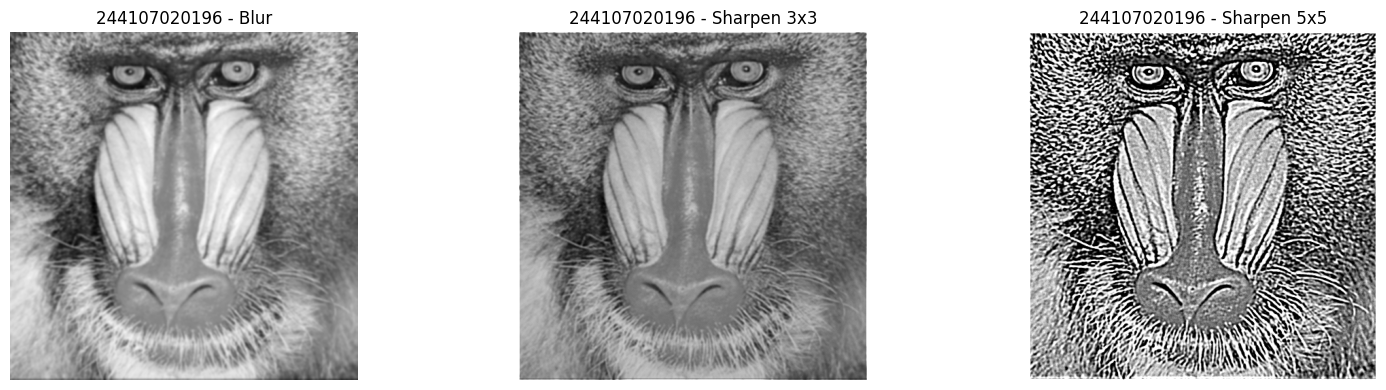

Blur       -> ketajaman: 32.5 | noise: 4.4
Sharpen 3x3-> ketajaman: 605.4 | noise: 13.3
Sharpen 5x5-> ketajaman: 9529.1 | noise: 72.6


In [9]:
# Citra dibuat sedikit buram terlebih dahulu
img_blur = cv.GaussianBlur(img_gray, (7, 7), 0)

# Kernel penajaman 3x3 dan 5x5
sharpen_3x3 = np.array([[0, -1, 0],
                        [-1, 5, -1],
                        [0, -1, 0]], dtype=np.float32)
sharpen_5x5 = np.array([[-1, -1, -1, -1, -1],
                        [-1, -1, -1, -1, -1],
                        [-1, -1, 25, -1, -1],
                        [-1, -1, -1, -1, -1],
                        [-1, -1, -1, -1, -1]], dtype=np.float32)

hasil_3x3 = convolution2d(img_blur, sharpen_3x3, 1, 1)
hasil_5x5 = convolution2d(img_blur, sharpen_5x5, 1, 2)

plt.figure(figsize=(16, 4))
for nomor, (gambar, judul) in enumerate([
    (img_blur, 'Blur'),
    (hasil_3x3, 'Sharpen 3x3'),
    (hasil_5x5, 'Sharpen 5x5'),
], 1):
    plt.subplot(1, 3, nomor)
    plt.imshow(gambar, cmap='gray')
    plt.title(NIM + ' - ' + judul)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Evaluasi: ketajaman (varians Laplacian) dan kadar noise
def ukur_ketajaman(image):
    return cv.Laplacian(image, cv.CV_64F).var()

def ukur_noise(image):
    laplacian = cv.Laplacian(image, cv.CV_64F)
    return 1.4826 * np.median(np.abs(laplacian - np.median(laplacian)))

print('Blur       -> ketajaman:', round(ukur_ketajaman(img_blur), 1),
      '| noise:', round(ukur_noise(img_blur), 1))
print('Sharpen 3x3-> ketajaman:', round(ukur_ketajaman(hasil_3x3), 1),
      '| noise:', round(ukur_noise(hasil_3x3), 1))
print('Sharpen 5x5-> ketajaman:', round(ukur_ketajaman(hasil_5x5), 1),
      '| noise:', round(ukur_noise(hasil_5x5), 1))

**Analisis Tugas 2:**
Kernel 3x3 cukup untuk mengembalikan ketajaman tepi pada citra yang sedikit
buram dan kadar noise-nya masih wajar. Kernel 5x5 menaikkan ketajaman lebih
tinggi, tetapi noise ikut terangkat karena jendela kernel yang lebih besar
memperkuat perbedaan intensitas yang kecil.

Untuk pemakaian sehari-hari, kernel **3x3** lebih optimal: tepi sudah jelas,
noise tidak berlebihan, dan hasilnya lebih alami. Kernel 5x5 dipakai hanya
saat citra memang sangat buram dan noise rendah.

### Tugas 3 — Kreasi: Filter Kartun Sederhana

Fungsi `kartun(image)` menggabungkan tiga langkah: penghalusan warna dengan
**Bilateral Filter**, deteksi garis tepi dengan **Adaptive Thresholding**, lalu
penggabungan keduanya dengan operasi **bitwise AND**.

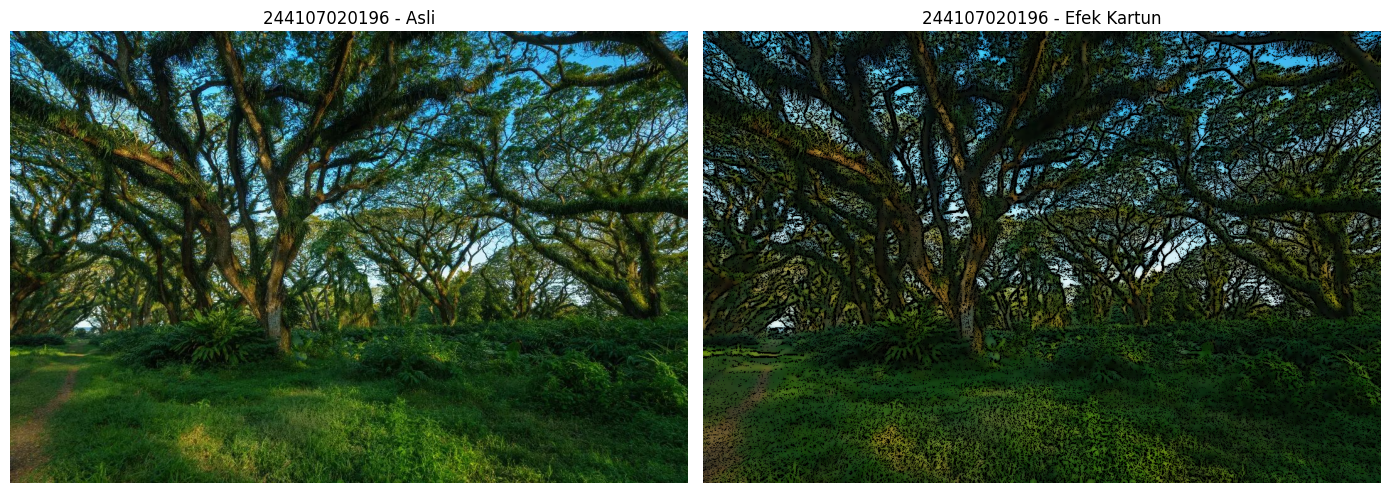

In [10]:
def kartun(image):
    # 1. Haluskan warna agar area warna menjadi rata
    warna = cv.bilateralFilter(image, 9, 250, 250)

    # 2. Deteksi garis tepi dengan adaptive threshold
    abu = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    tepi = cv.adaptiveThreshold(abu, 255,
                                cv.ADAPTIVE_THRESH_MEAN_C,
                                cv.THRESH_BINARY, 9, 9)
    tepi = cv.cvtColor(tepi, cv.COLOR_GRAY2BGR)

    # 3. Gabungkan warna dan garis tepi
    hasil = cv.bitwise_and(warna, tepi)
    return hasil

img_warna = cv.imread(str(DATA / 'djawatan.jpg'))
img_kartun = kartun(img_warna)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_warna, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Asli')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_kartun, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Efek Kartun')
plt.axis('off')
plt.tight_layout()
plt.show()

**Analisis Tugas 3:**
Bilateral filter meratakan warna pada area datar tetapi tetap menjaga batas
objek, sehingga warna terlihat seperti blok cat. Adaptive threshold mengambil
garis tepi berwarna hitam. Operasi AND menimpa garis tepi hitam ke atas citra
warna yang sudah rata, sehingga terbentuk efek kartun seperti pada aplikasi
populer.